# Part III: Quantifying Impact of ESG on Financial Performance

Does doing good mean doing well? 
- Report the regression results of financial performance on lagged ESG scores. 
- Does ESG predict future ROA after controlling for observable firm characteristics? Does ESG predict stock returns either unconditionally or after controlling for earnings news? 
- Please discuss your findings in the framework of financial materiality and impact materiality.

### Set-Up

In [1]:
import wrds
db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\alexj\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [2]:
# !pip install --quiet statsmodels seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from IPython.display import display

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

# Load the panel produced by data_prepare.ipynb.
# This notebook requires the extended CSV that includes dltt, dlc, xrd, and ppent.
# If those columns are missing, re-run data_prepare.ipynb first.
panel = pd.read_csv('esg_financial_panel_2013_2023.csv')
panel['datadate'] = pd.to_datetime(panel['datadate'])
panel['sic'] = pd.to_numeric(panel['sic'], errors='coerce')

required_ext = ['dltt', 'dlc', 'xrd', 'ppent']
missing_ext = [c for c in required_ext if c not in panel.columns]
if missing_ext:
    raise ValueError(
        f"Columns {missing_ext} are missing. "
        "Please re-run data_prepare.ipynb to regenerate "
        "esg_financial_panel_2013_2023.csv with the extended variable set."
    )

print(f'Loaded: {len(panel):,} firm-year observations')
print(f'Columns: {list(panel.columns)}')

Loaded: 20,758 firm-year observations
Columns: ['gvkey', 'permno', 'datadate', 'fyear', 'cusip8', 'sic', 'at', 'sale', 'ni', 'ceq', 'dltt', 'dlc', 'xrd', 'ppent', 'roa', 'size', 'lag_roa', 'lag_size', 'esg_score', 'future_roa', 'future_annual_ret', 'future_n_months_ret']


### Variable Construction

In [3]:
# Fama-French 48 industry classification, consistent with part1.ipynb
# Source: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_48_ind_port.html
FF48 = [
    (1,  'Agriculture',              [(100,199),(200,299),(700,799),(910,919),(2048,2048)]),
    (2,  'Food Products',            [(2000,2046),(2050,2063),(2070,2079),(2086,2086),(2090,2092),(2095,2095),(2096,2096),(2097,2099)]),
    (3,  'Candy & Soda',             [(2064,2068),(2086,2086),(2096,2096),(2097,2097)]),
    (4,  'Beer & Liquor',            [(2080,2085),(2080,2080)]),
    (5,  'Tobacco Products',         [(2100,2199)]),
    (6,  'Recreation',               [(7800,7833),(7840,7841),(7900,7999),(7993,7993),(7997,7997)]),
    (7,  'Entertainment',            [(7812,7819),(7820,7823),(7824,7829)]),
    (8,  'Printing & Publishing',    [(2700,2749),(2770,2771),(2780,2799)]),
    (9,  'Consumer Goods',           [(2047,2047),(2391,2392),(2510,2519),(2590,2599),(2840,2844),(2846,2849),(3160,3162),(3170,3172),(3190,3199),(3229,3229),(3260,3260),(3262,3263),(3269,3269),(3630,3639),(3750,3751),(3800,3800),(3860,3861),(3870,3879),(3910,3919),(3960,3969),(3991,3991),(3995,3995)]),
    (10, 'Apparel',                  [(2300,2390),(3020,3021),(3100,3111),(3130,3131),(3140,3149),(3150,3151),(3963,3965)]),
    (11, 'Healthcare',               [(8000,8099)]),
    (12, 'Medical Equipment',        [(3841,3851),(3841,3841),(3842,3842),(3843,3843),(3844,3844),(3845,3845),(3851,3851),(5047,5047),(5122,5122)]),
    (13, 'Pharmaceutical Products',  [(2830,2836)]),
    (14, 'Chemicals',                [(2800,2829),(2850,2879),(2890,2899)]),
    (15, 'Rubber & Plastic',         [(3000,3030),(3041,3041),(3050,3053),(3060,3069),(3070,3079),(3080,3089),(3090,3099)]),
    (16, 'Textiles',                 [(2200,2284),(2290,2295),(2297,2299),(2393,2395),(2397,2399)]),
    (17, 'Construction Materials',   [(800,899),(1500,1511),(1520,1542),(1550,1559),(1600,1699),(1711,1799),(2400,2439),(2450,2459),(2490,2499),(2660,2661),(2950,2952),(3200,3200),(3210,3211),(3240,3241),(3250,3259),(3261,3261),(3264,3264),(3270,3275),(3280,3281),(3290,3293),(3295,3299),(3420,3429),(3430,3433),(3440,3441),(3442,3442),(3446,3446),(3448,3448),(3449,3449),(3460,3469),(3490,3499),(3996,3996)]),
    (18, 'Steel Works',              [(3300,3300),(3310,3317),(3320,3325),(3330,3341),(3350,3357),(3360,3369),(3390,3399)]),
    (19, 'Fabricated Products',      [(3410,3412),(3443,3443),(3444,3444),(3460,3462),(3490,3492),(3494,3495),(3496,3499)]),
    (20, 'Machinery',                [(3510,3519),(3520,3529),(3530,3539),(3540,3549),(3550,3559),(3560,3569),(3580,3589),(3590,3599)]),
    (21, 'Electrical Equipment',     [(3600,3600),(3610,3613),(3620,3621),(3623,3629),(3640,3646),(3648,3649),(3660,3660),(3690,3692),(3699,3699)]),
    (22, 'Automobiles & Trucks',     [(2296,2296),(2396,2396),(3010,3011),(3537,3537),(3647,3647),(3694,3694),(3700,3716),(3750,3751),(3790,3792),(3799,3799)]),
    (23, 'Aircraft',                 [(3720,3721),(3723,3725),(3728,3729)]),
    (24, 'Shipbuilding',             [(3730,3731),(3740,3743)]),
    (25, 'Defense',                  [(3760,3769),(3480,3489),(3812,3812)]),
    (26, 'Precious Metals',          [(1040,1049)]),
    (27, 'Non-Metallic Mining',      [(1000,1039),(1050,1099),(1400,1499)]),
    (28, 'Coal',                     [(1200,1299)]),
    (29, 'Petroleum & Natural Gas',  [(1300,1399),(2900,2912),(2990,2999)]),
    (30, 'Utilities',                [(4900,4942),(4950,4952),(4953,4953),(4959,4959),(4961,4961),(4991,4991)]),
    (31, 'Communication',            [(4800,4899)]),
    (32, 'Personal Services',        [(7020,7021),(7040,7041),(7080,7081),(7200,7299),(7300,7300),(7389,7389),(7395,7395),(7500,7521),(7532,7534),(7536,7599),(7600,7641),(7690,7699),(8200,8499),(8600,8699),(8800,8899),(7510,7515)]),
    (33, 'Business Services',        [(7370,7379),(7380,7399),(7514,7515),(7519,7519),(8700,8748),(8900,8999),(4220,4229)]),
    (34, 'Computers',                [(3570,3579),(3680,3689),(3695,3695),(7373,7373)]),
    (35, 'Electronic Equipment',     [(3622,3622),(3661,3669),(3670,3679),(3810,3810),(3812,3812)]),
    (36, 'Measuring Instruments',    [(3811,3811),(3820,3829),(3830,3839)]),
    (37, 'Misc. Business',           [(3900,3999)]),
    (38, 'Transportation',           [(4000,4013),(4040,4049),(4100,4231),(4400,4499),(4600,4621),(4700,4789)]),
    (39, 'Wholesale',                [(5000,5199)]),
    (40, 'Retail',                   [(5200,5999)]),
    (41, 'Restaurants & Hotels',     [(5800,5829),(5890,5899),(7000,7011),(7041,7041)]),
    (42, 'Banking',                  [(6000,6199)]),
    (43, 'Insurance',                [(6300,6411)]),
    (44, 'Real Estate',              [(6500,6515),(6552,6553),(6798,6798)]),
    (45, 'Trading',                  [(6200,6299),(6710,6799)]),
]

sic_to_ff48 = {}
for ff_id, ff_name, ranges in FF48:
    for lo, hi in ranges:
        for s in range(lo, hi + 1):
            if s not in sic_to_ff48:
                sic_to_ff48[s] = (ff_id, ff_name)

def assign_ff48(sic):
    if pd.isna(sic):
        return (48, 'Other')
    return sic_to_ff48.get(int(sic), (48, 'Other'))

ff48_result = panel['sic'].apply(assign_ff48)
panel['ff48_id']  = ff48_result.apply(lambda x: x[0]).astype(int)
panel['industry'] = ff48_result.apply(lambda x: x[1])

print(f"Industry assignment complete. Unclassified: {(panel['industry'] == 'Other').sum():,} "
      f"({(panel['industry'] == 'Other').mean() * 100:.1f}%)")

Industry assignment complete. Unclassified: 1,009 (4.9%)


In [4]:
# Sort panel for computing lags within each firm
panel = panel.sort_values(['gvkey', 'fyear']).copy()

# Leverage: total debt (long-term + current) scaled by total assets.
# Missing debt fields are set to zero on the assumption that non-reporting
# reflects the absence of recorded debt obligations (consistent with, e.g.,
# Rajan and Zingales, 1995).
panel['leverage'] = (
    panel['dltt'].fillna(0) + panel['dlc'].fillna(0)
) / panel['at']

# R&D intensity: R&D expense scaled by total assets.
# Firms that do not report xrd are assigned zero, following the convention
# established in the innovation and intangibles literature.
panel['rd_intensity'] = panel['xrd'].fillna(0) / panel['at']

# Capital intensity: net PP&E scaled by total assets.
# Captures the degree to which a firm's asset base consists of tangible
# physical capital subject to environmental regulations.
panel['capital_intensity'] = panel['ppent'].fillna(0) / panel['at']

# Equity ratio: common equity scaled by total assets.
# Reflects balance sheet health; negative values occur for firms with
# accumulated losses exceeding paid-in capital.
panel['equity_ratio'] = panel['ceq'] / panel['at']

# Profit margin: net income scaled by net sales.
# Restricted to firm-years with positive sales to avoid undefined or
# economically uninterpretable values.
panel['profit_margin'] = np.where(
    panel['sale'] > 0,
    panel['ni'] / panel['sale'],
    np.nan
)

# Sales growth: year-over-year percentage change in net sales.
# Lagged sales are computed within each firm. Firm-years where
# lagged sales are non-positive are excluded.
panel['lag_sale'] = panel.groupby('gvkey')['sale'].shift(1)
panel['sales_growth'] = np.where(
    panel['lag_sale'] > 0,
    (panel['sale'] - panel['lag_sale']) / panel['lag_sale'],
    np.nan
)

# Report coverage for derived variables
new_vars = ['leverage', 'rd_intensity', 'capital_intensity',
            'equity_ratio', 'profit_margin', 'sales_growth']
print('Non-missing observations for derived variables:')
for v in new_vars:
    print(f'  {v:<22}: {panel[v].notna().sum():>6,}')

Non-missing observations for derived variables:
  leverage              : 20,758
  rd_intensity          : 20,758
  capital_intensity     : 20,758
  equity_ratio          : 20,758
  profit_margin         : 20,199
  sales_growth          : 16,996


In [5]:
panel = panel.sort_values(['gvkey', 'fyear']).copy()

def winsorize(series, lower=0.01, upper=0.99):
    """Winsorize a pandas Series at the specified quantile bounds."""
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)

# roa and size are raw in the CSV (winsorization in part1.ipynb was in-memory only).
# All derived variables are winsorized here before use in any table or regression.
winsorize_vars = [
    'roa', 'size',
    'leverage', 'rd_intensity', 'capital_intensity',
    'equity_ratio', 'profit_margin', 'sales_growth',
    'future_roa', 'future_annual_ret',          # outcome variables, first used in Part 3
]
for v in winsorize_vars:
    panel[v] = winsorize(panel[v])

print('Winsorization complete (1st and 99th percentiles).')

# earnings_news constructed after winsorization so it inherits the cleaned roa values
panel['earnings_news'] = panel['future_roa'] - panel['roa']

panel['fyear_str']   = panel['fyear'].astype(str)
panel['ff48_id_str'] = panel['ff48_id'].astype(str)

Winsorization complete (1st and 99th percentiles).


In [6]:
for col in panel.columns:
    print(f'{col:<20}  {panel[col].dtype}')

gvkey                 int64
permno                float64
datadate              datetime64[ns]
fyear                 int64
cusip8                object
sic                   float64
at                    float64
sale                  float64
ni                    float64
ceq                   float64
dltt                  float64
dlc                   float64
xrd                   float64
ppent                 float64
roa                   float64
size                  float64
lag_roa               float64
lag_size              float64
esg_score             float64
future_roa            float64
future_annual_ret     float64
future_n_months_ret   int64
ff48_id               int64
industry              object
leverage              float64
rd_intensity          float64
capital_intensity     float64
equity_ratio          float64
profit_margin         float64
lag_sale              float64
sales_growth          float64
earnings_news         float64
fyear_str             object
ff48_id_str   

In [7]:
panel

,gvkey,permno,datadate,fyear,cusip8,sic,at,sale,ni,ceq,...,leverage,rd_intensity,capital_intensity,equity_ratio,profit_margin,lag_sale,sales_growth,earnings_news,fyear_str,ff48_id_str
0,1004,54594.0,2017-05-31,2016,00036110,5080.0,1504.100,1767.600,56.500,914.200,...,0.104581,0.000000,0.240343,0.607805,0.031964,NaN,NaN,-0.027332,2016,39
1,1004,54594.0,2018-05-31,2017,00036110,5080.0,1524.700,1748.300,15.600,936.300,...,0.116220,0.000000,0.207647,0.614088,0.008923,1767.600,-0.010919,-0.005288,2017,39
2,1004,54594.0,2019-05-31,2018,00036110,5080.0,1517.200,2051.800,7.500,905.900,...,0.093396,0.000000,0.229897,0.597087,0.003655,1748.300,0.173597,-0.002827,2018,39
3,1004,54594.0,2020-05-31,2019,00036110,5080.0,2079.000,2089.300,4.400,902.600,...,0.329293,0.000000,0.210245,0.434151,0.002106,2051.800,0.018277,0.021135,2019,39
4,1004,54594.0,2021-05-31,2020,00036110,5080.0,1539.700,1651.400,35.800,974.400,...,0.133208,0.000000,0.246866,0.632851,0.021679,2089.300,-0.209592,0.026752,2020,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,339965,19654.0,2022-01-31,2021,83344510,7370.0,6649.698,1219.327,-679.948,5049.045,...,0.031024,0.070219,0.044428,0.759289,-0.557642,NaN,NaN,-0.000917,2021,33
20754,339965,19654.0,2023-01-31,2022,83344510,7370.0,7722.322,2065.659,-796.705,5456.436,...,0.032588,0.102049,0.050773,0.706580,-0.385690,1219.327,0.694098,0.001496,2022,33
20755,345556,16069.0,2021-12-31,2021,30315R10,2836.0,123.021,21.167,-31.283,96.857,...,0.107575,0.233700,0.033880,0.787321,-1.477914,NaN,NaN,NaN,2021,13
20756,347007,15533.0,2022-12-31,2022,45256X10,2836.0,362.356,0.240,-416.567,-447.327,...,1.019711,0.553478,0.523193,-0.453973,-34.603915,NaN,NaN,0.018635,2022,13


In [8]:
panel['fyear'].describe()

count    20758.000000
mean      2018.937374
std          2.774937
min       2013.000000
25%       2017.000000
50%       2019.000000
75%       2021.000000
max       2023.000000
Name: fyear, dtype: float64

In [9]:
panel['esg_score'].describe()

count    20758.000000
mean         0.404152
std          0.190924
min          0.069560
25%          0.253776
50%          0.373490
75%          0.538747
max          0.854176
Name: esg_score, dtype: float64

### Regression 1: Financial Performance on Lagged ESG Scores

In [10]:
# Create copy of panel with only the variables needed for regression tables to speed up estimation
reg1_vars = ['future_roa', 'esg_score', 'fyear_str', 'ff48_id_str']
sample_reg1 = panel.dropna(subset=reg1_vars).copy()

# Lag regression of financial performance on lagged ESG scores
reg1 = smf.ols(
    'future_roa ~ esg_score + C(fyear_str) + C(ff48_id_str)',
    data=sample_reg1
).fit(cov_type='HC3')

print("=== Regression 1: Future ROA ~ ESG Score (No Firm-Level Controls) ===")
print(f"N = {int(reg1.nobs):,}   R² = {reg1.rsquared:.4f}")
print(f"\n{'Variable':<20} {'Coef':>10} {'Std Err':>10} {'t':>8} {'p-value':>10}")
print("-" * 62)
for var in ['esg_score']:
    coef  = reg1.params[var]
    se    = reg1.bse[var]
    t     = reg1.tvalues[var]
    p     = reg1.pvalues[var]
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f"{var:<20} {coef:>10.4f} {se:>10.4f} {t:>8.2f} {p:>10.4f} {stars}")
print("\nYear FE: Yes    Industry FE: Yes    Controls: No")

=== Regression 1: Future ROA ~ ESG Score (No Firm-Level Controls) ===
N = 18,372   R² = 0.3323

Variable                   Coef    Std Err        t    p-value
--------------------------------------------------------------
esg_score                0.1526     0.0057    26.89     0.0000 ***

Year FE: Yes    Industry FE: Yes    Controls: No


### Regression 2: Future ROA on ESG Scores (Controlling for Firm Characteristics)

In [11]:
# Create copy of panel with all variables needed for regression tables to speed up estimation
reg2_vars = ['future_roa', 'esg_score', 'size', 'roa', 
             'leverage', 'rd_intensity', 'capital_intensity',
             'sales_growth', 'fyear_str', 'ff48_id_str']
sample_reg2 = panel.dropna(subset=reg2_vars).copy()

# Lag regression of financial performance on lagged ESG scores with firm-level controls
reg2 = smf.ols(
    'future_roa ~ esg_score + size + roa + leverage '
    '+ rd_intensity + capital_intensity + sales_growth + C(fyear_str) + C(ff48_id_str)',
    data=sample_reg2
).fit(cov_type='HC3')

print("=== Regression 2: Future ROA ~ ESG Score + Firm Controls ===")
print(f"N = {int(reg2.nobs):,}   R² = {reg2.rsquared:.4f}")
print(f"\n{'Variable':<22} {'Coef':>10} {'Std Err':>10} {'t':>8} {'p-value':>10}")
print("-" * 64)
for var in ['esg_score', 'size', 'roa', 'leverage',
            'rd_intensity', 'capital_intensity', 'sales_growth']:
    coef  = reg2.params[var]
    se    = reg2.bse[var]
    t     = reg2.tvalues[var]
    p     = reg2.pvalues[var]
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f"{var:<22} {coef:>10.4f} {se:>10.4f} {t:>8.2f} {p:>10.4f} {stars}")
print("\nYear FE: Yes    Industry FE: Yes    Controls: Yes")

=== Regression 2: Future ROA ~ ESG Score + Firm Controls ===
N = 14,834   R² = 0.5753

Variable                     Coef    Std Err        t    p-value
----------------------------------------------------------------
esg_score                  0.0311     0.0050     6.16     0.0000 ***
size                       0.0007     0.0006     1.13     0.2588 
roa                        0.6613     0.0157    42.01     0.0000 ***
leverage                   0.0210     0.0053     3.94     0.0001 ***
rd_intensity              -0.1021     0.0314    -3.25     0.0012 ***
capital_intensity          0.0047     0.0052     0.90     0.3680 
sales_growth              -0.0142     0.0047    -3.02     0.0026 ***

Year FE: Yes    Industry FE: Yes    Controls: Yes


### Regression 3: Stock Returns on ESG Scores (Unconditionally or After Controlling For Earnings News)

##### Proxy Earnings News
Proxy Earnings News: Difference between Future ROA and ROA

In [12]:
# 3a: Unconditional
ret1_vars = ['future_annual_ret', 'esg_score', 'fyear_str', 'ff48_id_str']
sample_ret1 = panel.dropna(subset=ret1_vars).copy()

reg_ret1 = smf.ols(
    'future_annual_ret ~ esg_score + C(fyear_str) + C(ff48_id_str)',
    data=sample_ret1
).fit(cov_type='HC3')

# 3b: Controlling for earnings news
ret2_vars = ['future_annual_ret', 'esg_score', 'earnings_news',
             'roa', 'size', 'leverage', 'sales_growth',
             'rd_intensity', 'capital_intensity',
             'fyear_str', 'ff48_id_str']
sample_ret2 = panel.dropna(subset=ret2_vars).copy()

reg_ret2 = smf.ols(
    'future_annual_ret ~ esg_score + earnings_news + roa '
    '+ size + leverage + sales_growth '
    '+ rd_intensity + capital_intensity '
    '+ C(fyear_str) + C(ff48_id_str)',
    data=sample_ret2
).fit(cov_type='HC3')

print("=== Regression 3a: Future Return ~ ESG Score (Unconditional) ===")
print(f"N = {int(reg_ret1.nobs):,}   R² = {reg_ret1.rsquared:.4f}")
coef  = reg_ret1.params['esg_score']
se    = reg_ret1.bse['esg_score']
p     = reg_ret1.pvalues['esg_score']
stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
print(f"  esg_score: {coef:.4f} ({se:.4f})  p={p:.4f} {stars}")
print("\nYear FE: Yes    Industry FE: Yes    Controls: No")

print("\n=== Regression 3b: Future Return ~ ESG + Earnings News + Controls ===")
print(f"N = {int(reg_ret2.nobs):,}   R² = {reg_ret2.rsquared:.4f}")
print(f"\n{'Variable':<22} {'Coef':>10} {'Std Err':>10} {'t':>8} {'p-value':>10}")
print("-" * 64)
for var in ['esg_score', 'earnings_news', 'roa', 'size', 'leverage', 'sales_growth', 'rd_intensity', 'capital_intensity']:
    coef  = reg_ret2.params[var]
    se    = reg_ret2.bse[var]
    t     = reg_ret2.tvalues[var]
    p     = reg_ret2.pvalues[var]
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f"{var:<22} {coef:>10.4f} {se:>10.4f} {t:>8.2f} {p:>10.4f} {stars}")
print("\nYear FE: Yes    Industry FE: Yes    Controls: Yes")

=== Regression 3a: Future Return ~ ESG Score (Unconditional) ===
N = 20,758   R² = 0.0778
  esg_score: -0.0360 (0.0173)  p=0.0380 **

Year FE: Yes    Industry FE: Yes    Controls: No

=== Regression 3b: Future Return ~ ESG + Earnings News + Controls ===
N = 14,834   R² = 0.1884

Variable                     Coef    Std Err        t    p-value
----------------------------------------------------------------
esg_score                 -0.0240     0.0246    -0.97     0.3305 
earnings_news              1.4029     0.0639    21.97     0.0000 ***
roa                        0.4230     0.0462     9.15     0.0000 ***
size                      -0.0035     0.0029    -1.18     0.2371 
leverage                   0.0479     0.0220     2.17     0.0299 **
sales_growth              -0.0273     0.0139    -1.97     0.0491 **
rd_intensity               0.5768     0.1046     5.51     0.0000 ***
capital_intensity          0.0071     0.0268     0.27     0.7907 

Year FE: Yes    Industry FE: Yes    Controls: Ye

#### SUE as Earnings News

In [13]:
# ── Step 1: Pull all firms from fundq — no gvkey restriction ──
# Removing the IN clause avoids the gvkey format mismatch in SQL.
# Matching to panel happens in pandas (Step 6) where dtype
# alignment is explicit and verifiable before the merge.

q_data = db.raw_sql("""
    SELECT gvkey, datadate, rdq, fyearq, fqtr, epspxq
    FROM comp.fundq
    WHERE indfmt  = 'INDL'
      AND datafmt = 'STD'
      AND consol  = 'C'
      AND popsrc  = 'D'
      AND rdq     IS NOT NULL
      AND epspxq  IS NOT NULL
      AND fyearq  >= 2008
""")

q_data['gvkey']    = q_data['gvkey'].astype(str).str.strip()
q_data['fqtr']     = pd.to_numeric(q_data['fqtr'],   errors='coerce')
q_data['fyearq']   = pd.to_numeric(q_data['fyearq'], errors='coerce')
q_data['datadate'] = pd.to_datetime(q_data['datadate'])
q_data['rdq']      = pd.to_datetime(q_data['rdq'])
q_data             = q_data.dropna(subset=['fqtr', 'fyearq', 'epspxq'])

print(f"Quarterly observations pulled: {len(q_data):,}")
print(f"Fiscal years covered: {q_data['fyearq'].min():.0f} – "
      f"{q_data['fyearq'].max():.0f}")
print(f"Unique gvkeys in fundq: {q_data['gvkey'].nunique():,}")

# Diagnose gvkey format before attempting any match
print("\nSample gvkeys from panel:")
print(panel['gvkey'].astype(str).str.strip().head(10).tolist())
print("\nSample gvkeys from fundq:")
print(q_data['gvkey'].head(10).tolist())
print("\nPanel gvkey lengths:")
print(panel['gvkey'].astype(str).str.strip().str.len().value_counts())
print("\nFundq gvkey lengths:")
print(q_data['gvkey'].str.len().value_counts())

Quarterly observations pulled: 553,604
Fiscal years covered: 2008 – 2026
Unique gvkeys in fundq: 17,156

Sample gvkeys from panel:
['1004', '1004', '1004', '1004', '1004', '1004', '1004', '1045', '1045', '1045']

Sample gvkeys from fundq:
['001004', '001004', '001004', '001004', '001013', '001013', '001013', '001013', '001019', '001021']

Panel gvkey lengths:
gvkey
5    11218
6     5159
4     4381
Name: count, dtype: int64

Fundq gvkey lengths:
gvkey
6    553604
Name: count, dtype: int64


In [14]:
# ── Step 2: Align gvkey format across both datasets ───────────
# After diagnosis, apply whichever normalization is needed.
# zfill(6) is the safest universal fix — WRDS gvkeys are always
# 6 characters zero-padded. If panel lost leading zeros via CSV
# roundtrip, zfill restores them. If they were never lost, zfill
# is a no-op on already 6-char strings.

panel['gvkey']  = panel['gvkey'].astype(str).str.strip().str.zfill(6)
q_data['gvkey'] = q_data['gvkey'].astype(str).str.strip().str.zfill(6)

# Verify overlap after normalization
panel_gvkeys = set(panel['gvkey'].unique())
fundq_gvkeys = set(q_data['gvkey'].unique())
overlap      = panel_gvkeys & fundq_gvkeys

print(f"Panel unique gvkeys:          {len(panel_gvkeys):,}")
print(f"Fundq unique gvkeys:          {len(fundq_gvkeys):,}")
print(f"Overlap after normalization:  {len(overlap):,} "
      f"({len(overlap)/len(panel_gvkeys)*100:.1f}% of panel)")
print(f"Panel gvkeys still missing:   "
      f"{len(panel_gvkeys - fundq_gvkeys):,} "
      f"— these firms have no quarterly filings in fundq")

Panel unique gvkeys:          3,350
Fundq unique gvkeys:          17,156
Overlap after normalization:  3,350 (100.0% of panel)
Panel gvkeys still missing:   0 — these firms have no quarterly filings in fundq


In [15]:
# ── Step 3: Deduplicate — keep latest restatement ────────────

print(f"Rows before dedup: {len(q_data):,}")
q_data = (
    q_data
    .sort_values(['gvkey', 'fyearq', 'fqtr', 'datadate'])
    .drop_duplicates(subset=['gvkey', 'fyearq', 'fqtr'], keep='last')
)
print(f"Rows after dedup:  {len(q_data):,}")

dupes = q_data.duplicated(subset=['gvkey', 'fyearq', 'fqtr']).sum()
assert dupes == 0, \
    f"{dupes:,} duplicate gvkey+fyearq+fqtr rows remain — investigate"
print("Confirmed: one row per gvkey + fyearq + fqtr")

Rows before dedup: 553,604
Rows after dedup:  553,314
Confirmed: one row per gvkey + fyearq + fqtr


In [16]:
# ── Step 4: Seasonal random walk surprise ─────────────────────

unique_qtrs = q_data.sort_values(['gvkey', 'fyearq', 'fqtr']).copy()

lag_eps = unique_qtrs[['gvkey', 'fyearq', 'fqtr', 'epspxq']].copy()
lag_eps.columns = ['gvkey', 'fyearq_next', 'fqtr', 'eps_lag4q']
lag_eps['fyearq'] = lag_eps['fyearq_next'] + 1
lag_eps = lag_eps.drop(columns='fyearq_next')

unique_qtrs = unique_qtrs.merge(
    lag_eps[['gvkey', 'fyearq', 'fqtr', 'eps_lag4q']],
    on=['gvkey', 'fyearq', 'fqtr'],
    how='left'
)

unique_qtrs['surprise'] = unique_qtrs['epspxq'] - unique_qtrs['eps_lag4q']

print(f"Surprises computed:   {unique_qtrs['surprise'].notna().sum():,}")
print(f"Missing (no lag EPS): {unique_qtrs['surprise'].isna().sum():,} "
      f"— expected for first year of each firm's history")

Surprises computed:   486,355
Missing (no lag EPS): 66,959 — expected for first year of each firm's history


In [17]:
# ── Step 5: Rolling sigma on lagged surprises ─────────────────

unique_qtrs = unique_qtrs.sort_values(['gvkey', 'datadate']).copy()

unique_qtrs['lag_surprise'] = (
    unique_qtrs.groupby('gvkey')['surprise'].shift(1)
)

unique_qtrs['sigma'] = (
    unique_qtrs
    .groupby('gvkey')['lag_surprise']
    .rolling(window=8, min_periods=4)
    .std()
    .reset_index(level=0, drop=True)
)
unique_qtrs = unique_qtrs.drop(columns=['lag_surprise'])

unique_qtrs['sue'] = unique_qtrs['surprise'] / unique_qtrs['sigma']
unique_qtrs['sue'] = unique_qtrs['sue'].replace([np.inf, -np.inf], np.nan)

print(f"Valid SUE observations: {unique_qtrs['sue'].notna().sum():,}")
print(f"NaN SUE:                {unique_qtrs['sue'].isna().sum():,}")

Valid SUE observations: 425,365
NaN SUE:                127,949


In [18]:
# ── Step 6: Isolate Q4 → annual SUE ──────────────────────────

sue_annual = (
    unique_qtrs[
        (unique_qtrs['fqtr']   == 4)   &
        (unique_qtrs['fyearq'] >= 2013) &
        (unique_qtrs['fyearq'] <= 2023)
    ]
    [['gvkey', 'fyearq', 'sue', 'sigma']]
    .rename(columns={
        'fyearq': 'fyear',
        'sue':    'sue_annual',
        'sigma':  'sigma_annual'
    })
    .dropna(subset=['sue_annual'])
)

dupes_annual = sue_annual.duplicated(subset=['gvkey', 'fyear']).sum()
print(f"Duplicate gvkey+fyear rows: {dupes_annual:,}")
if dupes_annual > 0:
    print("Resolving — likely fiscal year change events")
    sue_annual = sue_annual.drop_duplicates(
        subset=['gvkey', 'fyear'], keep='first'
    )

sue_annual['sue_annual']   = sue_annual['sue_annual'].astype(float)
sue_annual['sigma_annual'] = sue_annual['sigma_annual'].astype(float)

sue_annual['sue_annual'] = winsorize(sue_annual['sue_annual'])

print(f"\nAnnual SUE observations: {len(sue_annual):,}")
print(f"Unique gvkeys:           {sue_annual['gvkey'].nunique():,}")
print(f"Years covered:           {sorted(sue_annual['fyear'].unique())}")
print(f"\nSUE distribution:")
print(sue_annual['sue_annual'].describe().round(4))

Duplicate gvkey+fyear rows: 0

Annual SUE observations: 74,286
Unique gvkeys:           11,362
Years covered:           [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

SUE distribution:
count    73229.0000
mean        -0.0937
std          2.2587
min        -11.6609
25%         -0.6930
50%          0.0000
75%          0.8419
max          6.2862
Name: sue_annual, dtype: float64


In [19]:
# ── Step 7: Merge into panel ──────────────────────────────────
# Both gvkeys are now zfill(6) normalized — safe to merge.
# fyear alignment: fqtr=4 in fundq → fyearq = completed fiscal
# year = fyear in panel. Enforced in Step 6 above.

panel['fyear']      = panel['fyear'].astype(int)
sue_annual['fyear'] = sue_annual['fyear'].astype(int)

n_before  = len(panel)
panel_sue = panel.merge(
    sue_annual[['gvkey', 'fyear', 'sue_annual', 'sigma_annual']],
    on=['gvkey', 'fyear'],
    how='left'
)
n_after = len(panel_sue)

assert n_before == n_after, (
    f"Row count changed: {n_before:,} → {n_after:,}. "
    f"Duplicate gvkey+fyear in sue_annual — re-check Step 6."
)
print(f"Row count preserved: {n_before:,} → {n_after:,} ✓")

matched = panel_sue['sue_annual'].notna().sum()
print(f"Matched with SUE: {matched:,} ({matched/n_after*100:.1f}%)")
print(f"Unmatched:        {n_after - matched:,}")

coverage = (
    panel_sue.groupby('fyear')['sue_annual']
    .apply(lambda x: x.notna().mean() * 100)
    .round(1)
    .reset_index()
    .rename(columns={'sue_annual': 'coverage_%'})
)
print(f"\nSUE coverage by fiscal year:")
print(coverage.to_string(index=False))
low = coverage[coverage['coverage_%'] < 70]
if len(low) > 0:
    print(f"\nWARNING: Low coverage years: {low['fyear'].tolist()}")

Row count preserved: 20,758 → 20,758 ✓
Matched with SUE: 19,892 (95.8%)
Unmatched:        866

SUE coverage by fiscal year:
 fyear  coverage_%
  2013        99.3
  2014        98.5
  2015        96.0
  2016        96.0
  2017        94.6
  2018        94.2
  2019        94.4
  2020        93.2
  2021        94.7
  2022        98.1
  2023        99.7


In [20]:
print(panel_sue[['sue_annual', 'roa', 'earnings_news']].corr().round(3))

               sue_annual    roa  earnings_news
sue_annual          1.000  0.155         -0.055
roa                 0.155  1.000         -0.314
earnings_news      -0.055 -0.314          1.000


In [21]:
# ── Step 8: Robustness regressions — unconditional and conditional ──

# 8a: Unconditional — ESG only (mirrors reg_ret1 but on SUE sample)
ret_sue_vars_unconditional = ['future_annual_ret', 'esg_score',
                               'fyear_str', 'ff48_id_str']
sample_ret_sue_unc = panel_sue.dropna(subset=ret_sue_vars_unconditional).copy()

reg_ret_sue_unc = smf.ols(
    'future_annual_ret ~ esg_score + C(fyear_str) + C(ff48_id_str)',
    data=sample_ret_sue_unc
).fit(cov_type='HC3')

# 8b: Conditional — ESG + SUE + controls (mirrors reg_ret2)
ret_sue_vars_cond = ['future_annual_ret', 'esg_score', 'sue_annual',
                     'roa', 'size', 'leverage', 'sales_growth',
                     'rd_intensity', 'capital_intensity',
                     'fyear_str', 'ff48_id_str']
sample_ret_sue_cond = panel_sue.dropna(subset=ret_sue_vars_cond).copy()

reg_ret_sue_cond = smf.ols(
    'future_annual_ret ~ esg_score + sue_annual + roa '
    '+ size + leverage + sales_growth '
    '+ rd_intensity + capital_intensity '
    '+ C(fyear_str) + C(ff48_id_str)',
    data=sample_ret_sue_cond
).fit(cov_type='HC3')

# ── Print results ─────────────────────────────────────────────

print("=== Robustness 3a: Future Return ~ ESG Score (Unconditional) ===")
print(f"N = {int(reg_ret_sue_unc.nobs):,}   R² = {reg_ret_sue_unc.rsquared:.4f}")
coef  = reg_ret_sue_unc.params['esg_score']
se    = reg_ret_sue_unc.bse['esg_score']
p     = reg_ret_sue_unc.pvalues['esg_score']
stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
print(f"  esg_score: {coef:.4f} ({se:.4f})  p={p:.4f} {stars}")
print("  Year FE: Yes    Industry FE: Yes    Controls: No")

print("\n=== Robustness 3b: Future Return ~ ESG + Annual SUE + Controls ===")
print("    SUE = (EPS_Q4_t - EPS_Q4_{t-1}) / σ (rolling 8Q lagged surprises)")
print(f"N = {int(reg_ret_sue_cond.nobs):,}   R² = {reg_ret_sue_cond.rsquared:.4f}")
print(f"\n{'Variable':<22} {'Coef':>10} {'Std Err':>10} {'t':>8} {'p-value':>10}")
print("-" * 64)
for var in ['esg_score', 'sue_annual', 'roa', 'size',
            'leverage', 'sales_growth', 'rd_intensity', 'capital_intensity']:
    coef  = reg_ret_sue_cond.params[var]
    se    = reg_ret_sue_cond.bse[var]
    t     = reg_ret_sue_cond.tvalues[var]
    p     = reg_ret_sue_cond.pvalues[var]
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f"{var:<22} {coef:>10.4f} {se:>10.4f} {t:>8.2f} {p:>10.4f} {stars}")
print("\nYear FE: Yes    Industry FE: Yes    Controls: Yes")

# ── ESG coefficient comparison across all specs ───────────────
print("\n--- ESG Coefficient Robustness Comparison ---")
print(f"{'Specification':<40} {'Coef':>8} {'p-value':>10} {'Sig':>6}")
print("-" * 66)
specs = [
    ("Primary 3a (unconditional)",          reg_ret1),
    ("Primary 3b (earnings_news)",          reg_ret2),
    ("Robustness 3a (unconditional, SUE sample)", reg_ret_sue_unc),
    ("Robustness 3b (annual SUE)",          reg_ret_sue_cond),
]
for label, m in specs:
    c = m.params['esg_score']
    p = m.pvalues['esg_score']
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else '(n.s.)'
    print(f"{label:<40} {c:>8.4f} {p:>10.4f} {stars:>6}")

=== Robustness 3a: Future Return ~ ESG Score (Unconditional) ===
N = 20,758   R² = 0.0778
  esg_score: -0.0360 (0.0173)  p=0.0380 **
  Year FE: Yes    Industry FE: Yes    Controls: No

=== Robustness 3b: Future Return ~ ESG + Annual SUE + Controls ===
    SUE = (EPS_Q4_t - EPS_Q4_{t-1}) / σ (rolling 8Q lagged surprises)
N = 16,824   R² = 0.0951

Variable                     Coef    Std Err        t    p-value
----------------------------------------------------------------
esg_score                 -0.0064     0.0250    -0.26     0.7974 
sue_annual                 0.0108     0.0016     6.61     0.0000 ***
roa                       -0.1197     0.0478    -2.50     0.0122 **
size                      -0.0003     0.0029    -0.10     0.9175 
leverage                   0.0596     0.0214     2.79     0.0053 ***
sales_growth              -0.0378     0.0141    -2.69     0.0072 ***
rd_intensity               0.2623     0.1001     2.62     0.0088 ***
capital_intensity          0.0181     0.0271  

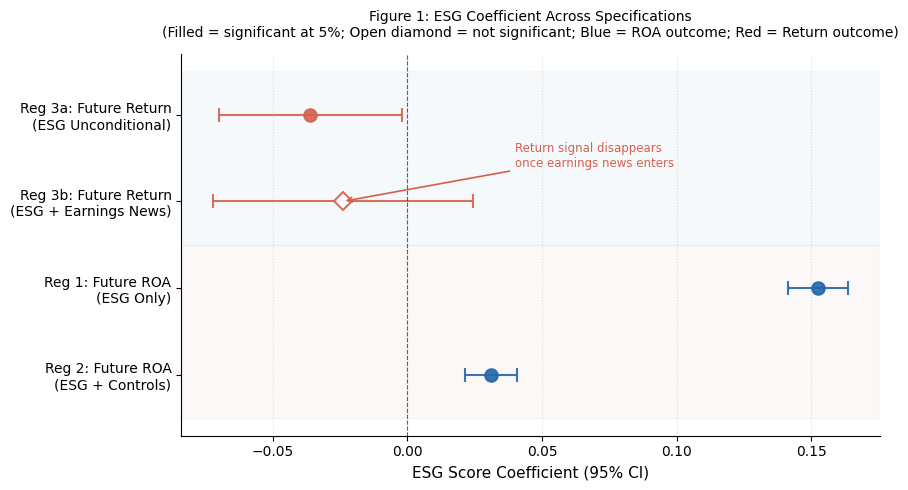

Figure 1 saved.


In [22]:
# Figure 1: ESG Coefficient Plot across all specifications

import scipy.stats as stats

fig1, ax = plt.subplots(figsize=(9, 5))

# ── Data: coefficients, SEs, labels, dependent variable group ─────────────────
specs = [
    # label,                          coef,    se,      dep_var group, significant
    ('Reg 2: Future ROA\n(ESG + Controls)',       0.0311,  0.0050,  'roa',    True),
    ('Reg 1: Future ROA\n(ESG Only)',             0.1526,  0.0057,  'roa',    True),
    ('Reg 3b: Future Return\n(ESG + Earnings News)', -0.0240, 0.0246, 'ret',  False),
    ('Reg 3a: Future Return\n(ESG Unconditional)', -0.0360, 0.0173,  'ret',   True),
]
# Ordered bottom-to-top on the y-axis
y_positions = range(len(specs))
ci_multiplier = 1.96  # 95% CI

colors = {
    'roa': '#2166ac',   # blue for ROA specs
    'ret': '#d6604d',   # red for return specs
}

for i, (label, coef, se, group, sig) in enumerate(specs):
    ci = ci_multiplier * se
    color = colors[group]
    # Filled circle = significant; open circle = not significant
    marker = 'o' if sig else 'D'
    mfc = color if sig else 'white'
    ax.errorbar(
        coef, i,
        xerr=ci,
        fmt=marker,
        color=color,
        markerfacecolor=mfc,
        markeredgecolor=color,
        markeredgewidth=1.5,
        markersize=9,
        capsize=5,
        capthick=1.5,
        linewidth=1.5,
        ecolor=color,
        alpha=0.9
    )

# Zero line
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

# Shaded regions to separate ROA vs return specs
ax.axhspan(1.5, 3.5, color=colors['roa'], alpha=0.04)
ax.axhspan(-0.5, 1.5, color=colors['ret'], alpha=0.04)

# Axis labels and formatting
ax.set_yticks(list(y_positions))
ax.set_yticklabels([s[0] for s in specs], fontsize=10)
ax.set_xlabel('ESG Score Coefficient (95% CI)', fontsize=11)
ax.set_title(
    'Figure 1: ESG Coefficient Across Specifications\n'
    '(Filled = significant at 5%; Open diamond = not significant; '
    'Blue = ROA outcome; Red = Return outcome)',
    fontsize=10, pad=12
)

# Annotation for the mediation story
ax.annotate(
    'Return signal disappears\nonce earnings news enters',
    xy=(-0.0240, 2), xytext=(0.04, 2.4),
    fontsize=8.5, color='#d6604d',
    arrowprops=dict(arrowstyle='->', color='#d6604d', lw=1.2),
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('part3_figure1_coef_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")






Figure 1: ESG Coefficient Across SpecificationsThis chart shows the ESG regression coefficient and 95% confidence interval across all four specifications. The color coding separates the two outcome variables: blue for ROA, red for stock returns.On the ROA side, both coefficients are positive and statistically significant. The unconditional estimate (Reg 1) is 0.153, which drops to 0.031 once we add firm-level controls in Reg 2. The drop makes sense: larger, more profitable firms score higher on ESG and also tend to be more profitable next year. Once you account for that, the ESG signal shrinks but holds. Both CIs stay comfortably to the right of zero.The return results tell a different story. Unconditionally, ESG predicts lower future returns (coef = -0.036, p = 0.038). That's a real but weak signal. When we add earnings news in Reg 3b, the coefficient collapses to -0.024 and becomes statistically indistinguishable from zero. The open diamond sitting on the zero line is the key visual. The ESG return signal is not a market pricing effect. It runs through earnings.

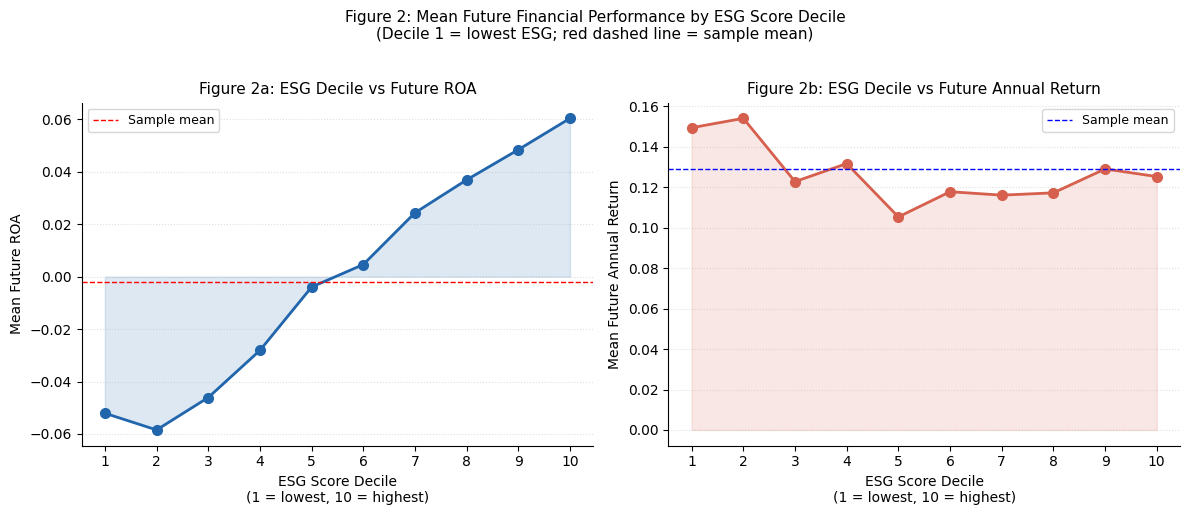

Figure 2 saved.


In [23]:
# ── Figure 2: ESG Decile vs Future ROA and Future Annual Return ────────────────

# Assign ESG deciles on the full panel
panel['esg_decile'] = pd.qcut(panel['esg_score'], q=10, labels=False) + 1

decile_stats = (
    panel
    .dropna(subset=['esg_decile', 'future_roa', 'future_annual_ret'])
    .groupby('esg_decile')
    .agg(
        mean_future_roa=('future_roa', 'mean'),
        mean_future_ret=('future_annual_ret', 'mean'),
        n=('future_roa', 'count')
    )
    .reset_index()
)

fig2, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Panel A: ESG Decile vs Future ROA ─────────────────────────────────────────
ax1 = axes[0]
ax1.fill_between(
    decile_stats['esg_decile'],
    decile_stats['mean_future_roa'],
    alpha=0.15, color='#2166ac'
)
ax1.plot(
    decile_stats['esg_decile'],
    decile_stats['mean_future_roa'],
    color='#2166ac', linewidth=2, marker='o', markersize=7
)
ax1.axhline(
    panel['future_roa'].mean(), color='red',
    linestyle='--', linewidth=1, label='Sample mean'
)
ax1.set_xlabel('ESG Score Decile\n(1 = lowest, 10 = highest)', fontsize=10)
ax1.set_ylabel('Mean Future ROA', fontsize=10)
ax1.set_title('Figure 2a: ESG Decile vs Future ROA', fontsize=11)
ax1.set_xticks(range(1, 11))
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

# ── Panel B: ESG Decile vs Future Annual Return ────────────────────────────────
ax2 = axes[1]
ax2.fill_between(
    decile_stats['esg_decile'],
    decile_stats['mean_future_ret'],
    alpha=0.15, color='#d6604d'
)
ax2.plot(
    decile_stats['esg_decile'],
    decile_stats['mean_future_ret'],
    color='#d6604d', linewidth=2, marker='o', markersize=7
)
ax2.axhline(
    panel['future_annual_ret'].mean(), color='blue',
    linestyle='--', linewidth=1, label='Sample mean'
)
ax2.set_xlabel('ESG Score Decile\n(1 = lowest, 10 = highest)', fontsize=10)
ax2.set_ylabel('Mean Future Annual Return', fontsize=10)
ax2.set_title('Figure 2b: ESG Decile vs Future Annual Return', fontsize=11)
ax2.set_xticks(range(1, 11))
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle=':', alpha=0.4)

fig2.suptitle(
    'Figure 2: Mean Future Financial Performance by ESG Score Decile\n'
    '(Decile 1 = lowest ESG; red dashed line = sample mean)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('part3_figure2_decile_means.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

Figure 2: ESG Decile vs Future Financial Performance

Panel A (Future ROA): The gradient here is about as clean as you'll get in real data. Firms in the bottom ESG decile average about -0.06 future ROA. Firms in the top decile average about +0.06. The steepest gains come in the lower half (deciles 1 to 5), then the curve flattens out. The sample mean sits near zero, which reflects the mix of profitable firms and loss-makers (especially pharma and early-stage growth companies) in the panel. This is the clearest raw evidence that ESG is linked to future operating performance.
Panel B (Future Returns): Flat. Returns cluster around 13% across all ten deciles with no directional pattern. Deciles 1 and 2 look slightly higher but it does not hold across the range. This is exactly what the regressions show: once you account for the fact that high-ESG firms also tend to have different earnings trajectories, there is no return premium to capture.

ESG predicts future profitability, consistently and across both the raw data and the regressions. ESG does not predict future returns once earnings are in the model. That distinction matters for how we frame financial materiality in the writeup: ESG has operational relevance, but the market appears to price it in already.

### Discussion of findings in the framework of financial materiality and impact materiality.
